### Example notebook for processing and computing CP-DINO embeddings on the PERISCOPE dataset

This notebook demonstrates the integration of **Sequencing By Synthesis (SBS)** imaging with **Cell Painting** morphological profiling using the PERISCOPE dataset. The workflow covers:

1. **Data Loading** — Fetching SBS and Cell Painting images from the Cell Painting Gallery
2. **Image Registration** — Aligning Cell Painting images to SBS coordinate space
3. **Barcode Calling** — Detecting and sequencing optical barcodes across SBS cycles
4. **Cell Segmentation** — Identifying cell boundaries using Cellpose
5. **Barcode-to-Cell Assignment** — Linking detected barcodes to segmented cells
6. **Feature Extraction** — Generating single-cell embeddings using CP-DINO

(Ramezani, M., Weisbart, E., Bauman, J. et al. A genome-wide atlas of human cell morphology. Nat Methods 22, 621–633 (2025). https://doi.org/10.1038/s41592-024-02537-7)

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

from scipy.ndimage import gaussian_filter
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift as ndi_shift
import matplotlib.pyplot as plt
from cellpose import models


from cp_posh.utils import data
from cp_posh.utils.scaling import rescale_intensity
from cp_posh.sequencing import blob_log_base_caller
from cp_posh.sequencing.sequence_barcodes import sequence_barcodes_per_fov
from cp_posh.ssl.inference import get_model_cp_dino

### 1. Data Loading

Load SBS images across 12 sequencing cycles (4 base channels per cycle) and Cell Painting images (5 channels: DAPI, ER, WGA, Phalloidin, Mito) from the Cell Painting Gallery S3 bucket. 

Images are loaded from this path https://cellpainting-gallery.s3.amazonaws.com/index.html#cpg0021-periscope/broad/images/20200805_A549_WG_Screen/images_corrected_cropped/

In [ ]:
# using a single well, site and 1000x1000 crop as an example.
# Orchestration for processing the complete dataset would involve iterating full image over all wells and sites.
well = 1
site = 25

sbs_images = {}
for cycle in tqdm(range(1, 13)):
    ims = []
    for base in ['A', 'C', 'G', 'T']:
        ims.append(data.read_image(f"cellpainting-gallery/cpg0021-periscope/broad/images/20200805_A549_WG_Screen/images_corrected_cropped/CP186A_Well{well}/Cycle{cycle:02d}_{base}/Cycle{cycle:02d}_{base}_Site_{site}.tiff")[1000:2000, 1000:2000])
    sbs_images[cycle] = np.stack(ims, axis=0)

sbs_dapi_image = data.read_image(f"cellpainting-gallery/cpg0021-periscope/broad/images/20200805_A549_WG_Screen/images_corrected_cropped/CP186A_Well{well}/Cycle01_DAPI/Cycle01_DAPI_Site_{site}.tiff")[1000:2000, 1000:2000]
cellpaint_images = []
# load images in expected channel order for inference = DAPI, CONA, WGA, PHALLOIDIN, MITOPROBE
for channel in ["CorrDNA", "CorrER", "CorrWGA", "CorrPhalloidin", "CorrMito"]:
    cellpaint_images.append(data.read_image(f"cellpainting-gallery/cpg0021-periscope/broad/images/20200805_A549_WG_Screen/images_corrected_cropped/CP186A_Well{well}/{channel}/{channel}_Site_{site}.tiff")[1000:2000, 1000:2000])
cellpaint_image = np.stack(cellpaint_images, axis=0)

### 2. Image Registration

Align Cell Painting images to the SBS coordinate space using phase cross-correlation between the DAPI channels. This registration enables spatial correspondence between morphological features and barcode locations.

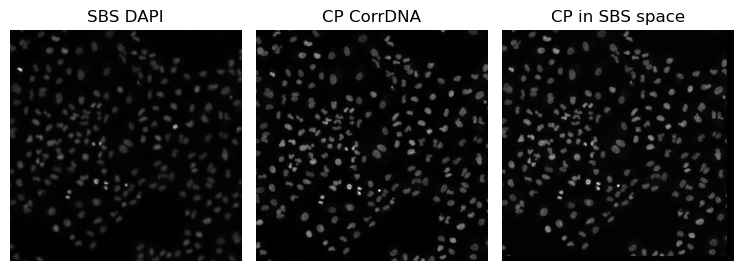

In [4]:
moving = cellpaint_image[0].astype(np.float32)
reference = sbs_dapi_image.astype(np.float32)

shift, error, _ = phase_cross_correlation(reference, moving, upsample_factor=10)
cellpaint_image_shifted = ndi_shift(cellpaint_image, shift=(0, *shift), order=1, mode='constant')

plt.figure(figsize=(10, 4))
plt.subplot(1, 4, 2); plt.title("SBS DAPI"); plt.imshow(reference, cmap='gray'); plt.axis('off')
plt.subplot(1, 4, 3); plt.title("CP CorrDNA"); plt.imshow(moving, cmap='gray'); plt.axis('off')
plt.subplot(1, 4, 4); plt.title("CP in SBS space"); plt.imshow(cellpaint_image_shifted[0], cmap='gray'); plt.axis('off')
plt.tight_layout()

### 3. Barcode Calling

Detect fluorescent spots using one of the base calling methods, call bases at each spot across cycles, and assemble complete 12-mer barcodes. Barcodes are then mapped to the sgRNA library to identify perturbation targets.

In [ ]:
# barcodes.csv can be obtained from this location: https://cellpainting-gallery.s3.amazonaws.com/index.html#cpg0021-periscope/broad/workspace/metadata/20200805_A549_WG_Screen/
sgrna_lib = pd.read_csv("barcodes.csv")

base_calls = {}
for cycle, ims in tqdm(sbs_images.items()):
    base_calls[cycle] = blob_log_base_caller.call_bases(ims, base_map={1: 'A', 2: 'C', 3: 'G', 4: 'T'})

base_calls_all = []
for cycle, bc in base_calls.items():
    bc['cycle'] = cycle
    bc['field_id'] = site
    bc['well_loc'] = well
    base_calls_all.append(bc)

barcodes_df = sequence_barcodes_per_fov(pd.concat(base_calls_all), distance_cutoff=5)

sgrna_lib['barcode'] = sgrna_lib['sgRNA'].apply(lambda x: x[0:12])
barcodes_df = barcodes_df.merge(sgrna_lib, on='barcode', how='inner')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:22<00:00,  1.84s/it]


### 4. Cell Segmentation

Segment cells using Cellpose with the cytoplasm model. Phalloidin channel (actin stain) provides clear cell boundaries for accurate segmentation.

In [ ]:
model = models.Cellpose(gpu=True, model_type="cyto", torch=True, net_avg=True)

# Phalloidin channel (index 3) for cell boundary detection
dapi_image = rescale_intensity(cellpaint_image_shifted[0], 0.1, 99.9, clip=True)
phalloidin_image = rescale_intensity(cellpaint_image_shifted[3], 0.1, 99.9, clip=True)
cyto_mask = model.eval(
    [np.array([dapi_image, phalloidin_image])],
    channels=[2, 1],
    diameter=None,
    rescale=None,
    cellprob_threshold=0.0,
    flow_threshold=0.4,
    resample=False,
    normalize=False,
)[0][0]

### 5. Visualization

Overlay segmentation masks and detected barcodes on both Cell Painting and SBS images to verify registration quality and barcode-cell correspondence.

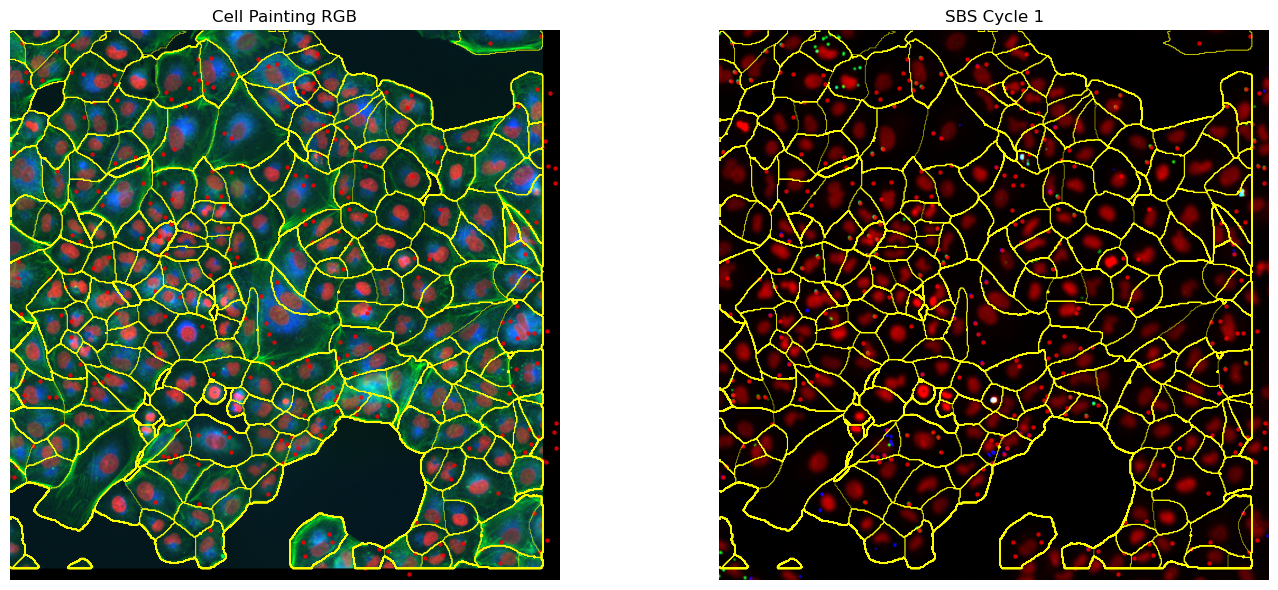

In [7]:
# RGB composite: DNA (red), Phalloidin (green), WGA (blue)
rgb_cp_image = np.stack([
    cellpaint_image_shifted[0],
    cellpaint_image_shifted[3],
    cellpaint_image_shifted[2]
], axis=-1)
rgb_cp_image = np.stack([rescale_intensity(rgb_cp_image[..., ch], clip=True) for ch in range(rgb_cp_image.shape[-1])], axis=-1)
rgb_sbs_image = np.stack([rescale_intensity(sbs_dapi_image, clip=True)] + [rescale_intensity(sbs_images[1][i], clip=True) for i in range(2)], axis=-1)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.title("Cell Painting RGB")
plt.imshow(rgb_cp_image)
plt.contour(cyto_mask, levels=np.unique(cyto_mask)[1:], colors='yellow', linewidths=0.5, alpha=0.7)
plt.scatter(barcodes_df.x, barcodes_df.y, c='red', s=5, alpha=0.7)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("SBS Cycle 1")
plt.imshow(rgb_sbs_image)
plt.contour(cyto_mask, levels=np.unique(cyto_mask)[1:], colors='yellow', linewidths=0.5, alpha=0.7)
plt.scatter(barcodes_df.x, barcodes_df.y, c='red', s=5, alpha=0.7)
plt.axis('off')

plt.tight_layout()
plt.show()

### 6. Single-Cell Cropping

Extract 224×224 pixel crops centered on each segmented cell. A Gaussian-smoothed mask isolates the target cell from neighboring cells within each crop.

In [8]:
unique_labels = sorted(np.unique(cyto_mask))[1:]

cell_crops = {}
cell_masks = {}
crop_info = []
crop_size = 224
half_crop = crop_size // 2

# Rescale to uint8 for inference
cellpaint_image_shifted_rescaled = (np.stack(
    [rescale_intensity(cellpaint_image_shifted[ch], clip=True) for ch in range(cellpaint_image_shifted.shape[0])],
    axis=0
) * 255).astype(np.uint8)

for label in unique_labels:
    y_coords, x_coords = np.where(cyto_mask == label)
    if len(y_coords) == 0:
        continue

    center_y, center_x = int(np.mean(y_coords)), int(np.mean(x_coords))

    y_start = max(0, center_y - half_crop)
    y_end = min(cellpaint_image_shifted_rescaled.shape[1], center_y + half_crop)
    x_start = max(0, center_x - half_crop)
    x_end = min(cellpaint_image_shifted_rescaled.shape[2], center_x + half_crop)

    if (y_end - y_start) < crop_size // 2 or (x_end - x_start) < crop_size // 2:
        continue

    crop = cellpaint_image_shifted_rescaled[:, y_start:y_end, x_start:x_end]
    mask_crop = cyto_mask[y_start:y_end, x_start:x_end]
    cell_mask = (mask_crop == label).astype(np.uint8)

    # Pad to 224x224 if needed
    if crop.shape[1] != crop_size or crop.shape[2] != crop_size:
        pad_y, pad_x = crop_size - crop.shape[1], crop_size - crop.shape[2]
        pad_top, pad_left = pad_y // 2, pad_x // 2
        pad_bottom, pad_right = pad_y - pad_top, pad_x - pad_left
        cell_mask = np.pad(cell_mask, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant')
        crop = np.pad(crop, ((0, 0), (pad_top, pad_bottom), (pad_left, pad_right)), mode='constant')

    # Apply Gaussian-smoothed mask to isolate target cell
    cell_mask = gaussian_filter(cell_mask.astype(float), sigma=2)
    if cell_mask.max() > 0:
        cell_mask = cell_mask / cell_mask.max()
    crop = cell_mask * crop

    cell_crops[label] = crop
    cell_masks[label] = cell_mask
    crop_info.append({
        'label': label,
        'center_y': center_y,
        'center_x': center_x,
        'crop_bounds': (y_start, y_end, x_start, x_end),
        'crop_size': (crop.shape[1], crop.shape[2])
    })

single_cell_tiles_df = pd.DataFrame(crop_info)

### 7. Barcode-to-Cell Assignment

Assign barcodes to cells based on spatial overlap with segmentation masks. Cells with multiple barcodes or ambiguous assignments are filtered out to ensure reliable perturbation labels.

In [9]:
barcodes_with_labels = []

for _, barcode_row in barcodes_df.iterrows():
    x, y = int(barcode_row['x']), int(barcode_row['y'])

    if 0 <= y < cyto_mask.shape[0] and 0 <= x < cyto_mask.shape[1]:
        cell_label = cyto_mask[y, x]
        if cell_label > 0:
            barcode_data = barcode_row.to_dict()
            barcode_data['cell_label'] = cell_label
            barcodes_with_labels.append(barcode_data)

barcodes_with_labels_df = pd.DataFrame(barcodes_with_labels)

In [10]:
# Filter to cells with exactly one unique barcode
barcodes_with_labels_df = (barcodes_with_labels_df
    .drop_duplicates(["sgRNA", "cell_label"])
    .drop_duplicates("cell_label", keep=False)
    .reset_index(drop=True))

### 8. Feature Extraction with CP-DINO

Generate single-cell morphological embeddings using CP-DINO self-supervised model

In [11]:
cpdino_1640 = get_model_cp_dino(model_name="cp-dino-1640")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
# Channel order and normalization constants
CHANNEL_ORDER = [0, 1, 2, 3, 4]
NORMALIZE_MEAN = (4.89883638, 7.92730405, 9.47751658, 10.16663979, 4.09869388)
NORMALIZE_STD = (15.66504555, 18.897298, 19.45658873, 20.57687824, 15.01226514)

In [ ]:
input_batch = torch.tensor(np.array(list(cell_crops.values())))[:, CHANNEL_ORDER].float()
input_batch = (input_batch - torch.tensor(NORMALIZE_MEAN).view(1, -1, 1, 1)) / torch.tensor(NORMALIZE_STD).view(1, -1, 1, 1)

embeddings = cpdino_1640(input_batch)